# Example evaluation notebook for the flopsmeter

## Floating points operation performance measurements for Nvidia RTX5080

This program performs a matrix multiplication and measures the elapsed time. This is how we get the operation speed (Gflops).

For now, we'll just focus on the performance of the fp32 numbers.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
matplotlib.rcParams['figure.figsize'] = [14, 7]
print("Python version:", sys.version)
print("Numpy version:", np.version.full_version)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", matplotlib.__version__)

Python version: 3.12.7 (main, Oct 15 2024, 17:58:55) [GCC 10.2.1 20210110]
Numpy version: 1.26.4
Pandas version: 2.2.3
Matplotlib version: 3.9.2


## How does workgroup size affect performance?

In [63]:
#build a heatmap !
def gflop_heatmap(data, matrix_size):
    datapivot = data.pivot(index="localsize0", columns="localsize1", values="Gflops")
    datapivot.sort_index(axis=0, inplace=True)
    datapivot.sort_index(axis=1, inplace=True)
    print("Maximal performance at:\n", data.loc[data["Gflops"].idxmax()])
    fig, ax0 = plt.subplots()
    ax0.set_aspect('equal', 'box')
    p = ax0.pcolormesh(datapivot)
    fig.colorbar(p, label="Gflops")
    ax0.set_xlabel("local_size[1]")
    ax0.set_ylabel("local_size[0]")
    fig.suptitle(f"Floating point performance in various workgroup sizes\n{matrix_size=} multiplications")

Maximal performance at:
 localsize0       8.000000
localsize1      12.000000
time_matmul      0.000814
Gflops         530.548580
Name: 396, dtype: float64


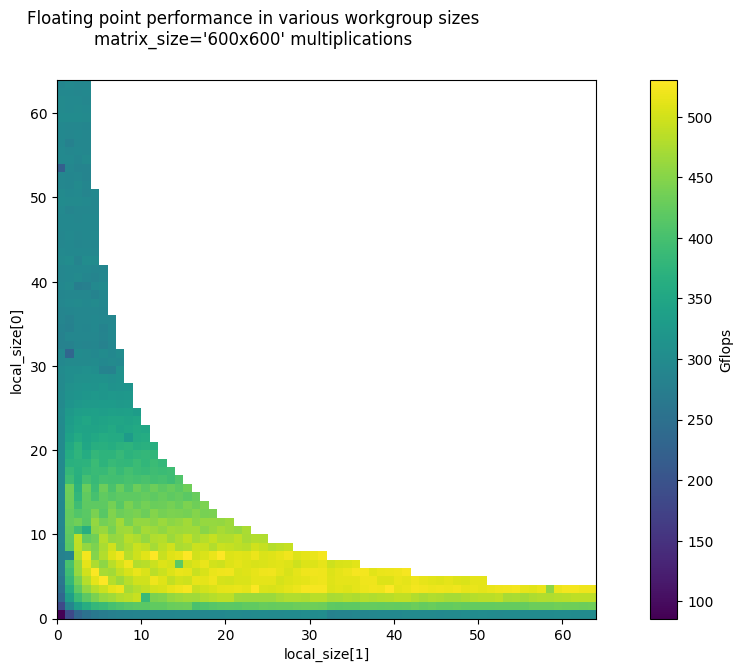

Maximal performance at:
 localsize0       8.000000
localsize1      28.000000
time_matmul      0.004086
Gflops         845.443105
Name: 412, dtype: float64


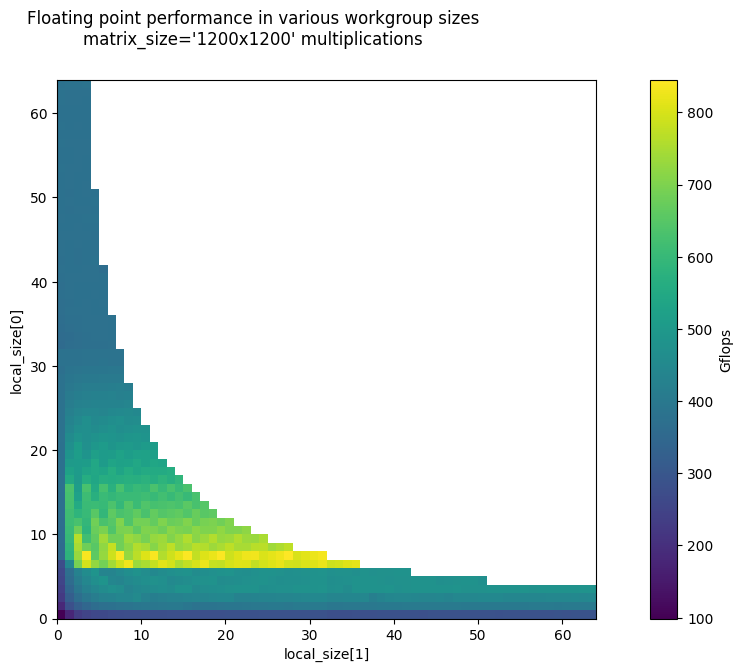

Maximal performance at:
 localsize0      10.000000
localsize1       3.000000
time_matmul      0.013608
Gflops         856.896702
Name: 447, dtype: float64


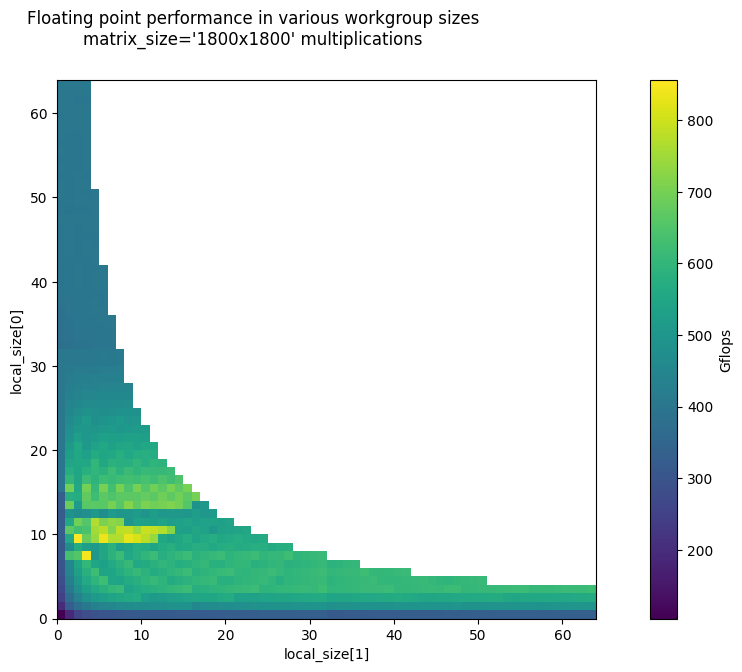

Maximal performance at:
 localsize0        8.000000
localsize1       28.000000
time_matmul       0.027058
Gflops         1021.574730
Name: 412, dtype: float64


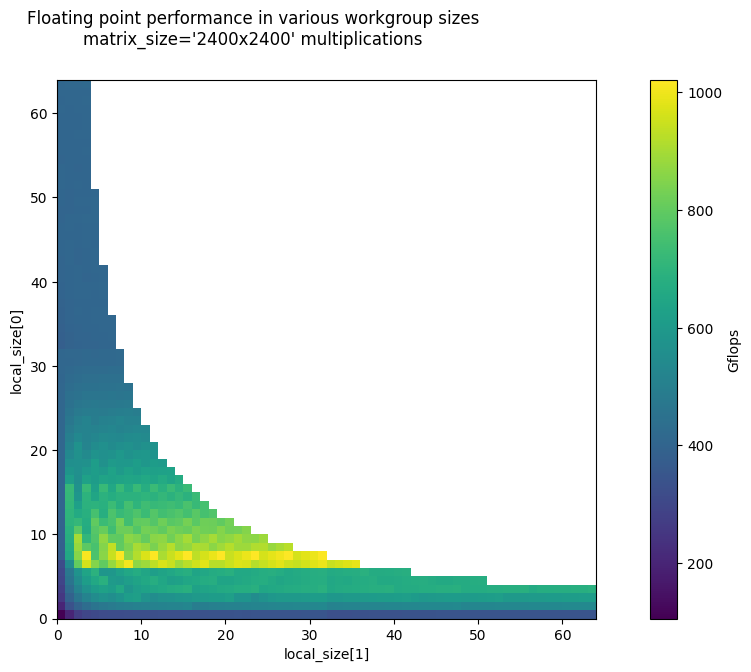

Maximal performance at:
 localsize0       8.000000
localsize1      32.000000
time_matmul      0.073309
Gflops         736.480677
Name: 416, dtype: float64


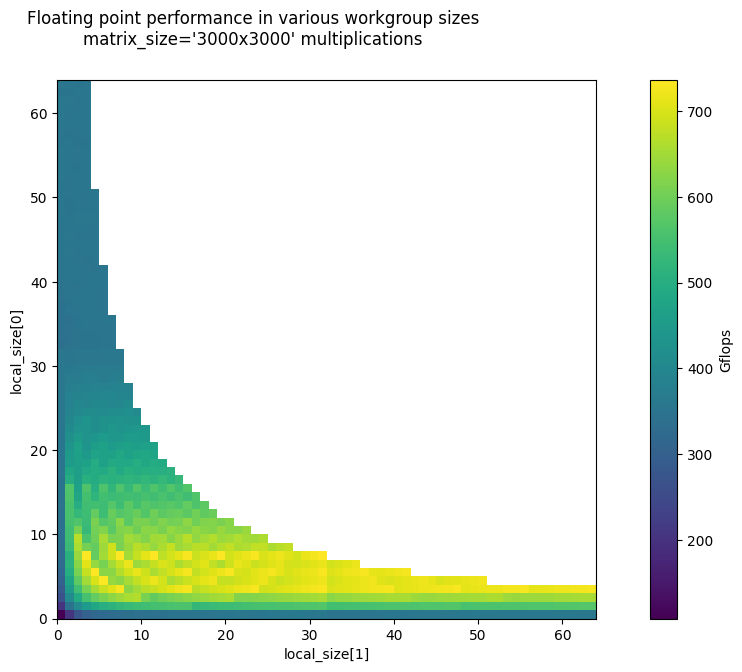

In [64]:
for matrix_size in (600, 1200, 1800, 2400, 3000):
    gflop_heatmap(
            pd.read_csv(f"data/opencl_matmul_test_output_20250521_size{matrix_size}_rtx5080.txt", sep=" ", comment="#"),
            f"{matrix_size}x{matrix_size}"
    )
    plt.show()